<a href="https://colab.research.google.com/github/244107020170-png/machine-learning/blob/main/JS05Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB ASSIGNMENT 1 — KNN Voice Classification

In [1]:
import pandas as pd

df = pd.read_csv('voice.csv')

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [3]:
df.describe()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


In [4]:
df['label'].value_counts()

,count
label,
male,1584
female,1584


In [5]:
print("=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

print("\n=== LABEL DISTRIBUTION ===")
print(df['label'].value_counts())

print("\n=== LABEL DISTRIBUTION (%) ===")
print(df['label'].value_counts(normalize=True) * 100)

=== DESCRIPTIVE STATISTICS ===


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374



=== LABEL DISTRIBUTION ===
label
male      1584
female    1584
Name: count, dtype: int64

=== LABEL DISTRIBUTION (%) ===
label
male      50.0
female    50.0
Name: proportion, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fitur dan target
X = df.drop('label', axis=1)
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Standardisasi
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train_scaled.shape)
print("Testing data :", X_test_scaled.shape)

Training data: (2217, 20)
Testing data : (951, 20)


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN menggunakan semua 20 fitur
knn_all = KNeighborsClassifier(n_neighbors=5)

knn_all.fit(X_train_scaled, y_train)

# Prediksi
y_pred_all = knn_all.predict(X_test_scaled)

# Accuracy
accuracy_all = accuracy_score(y_test, y_pred_all)

print("Accuracy KNN dengan semua fitur:", accuracy_all)

Accuracy KNN dengan semua fitur: 0.9737118822292324


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

feature_results = []

for feature in X.columns:
    # Ambil satu fitur
    X_train_feature = X_train[[feature]]
    X_test_feature = X_test[[feature]]

    # Standardisasi
    scaler_feature = StandardScaler()
    X_train_f = scaler_feature.fit_transform(X_train_feature)
    X_test_f = scaler_feature.transform(X_test_feature)

    # KNN
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_f, y_train)

    # Evaluasi
    pred = model.predict(X_test_f)
    acc = accuracy_score(y_test, pred)

    feature_results.append({
        'Feature': feature,
        'Accuracy': acc
    })

feature_results_df = pd.DataFrame(feature_results)
feature_results_df = feature_results_df.sort_values(
    by='Accuracy', ascending=False
).reset_index(drop=True)

display(feature_results_df)

,Feature,Accuracy
0,meanfun,0.952681
1,IQR,0.908517
2,Q25,0.868559
3,sd,0.800210
4,sp.ent,0.718191
5,mode,0.692955
6,sfm,0.674027
7,mindom,0.616193
8,dfrange,0.610936
9,skew,0.603575


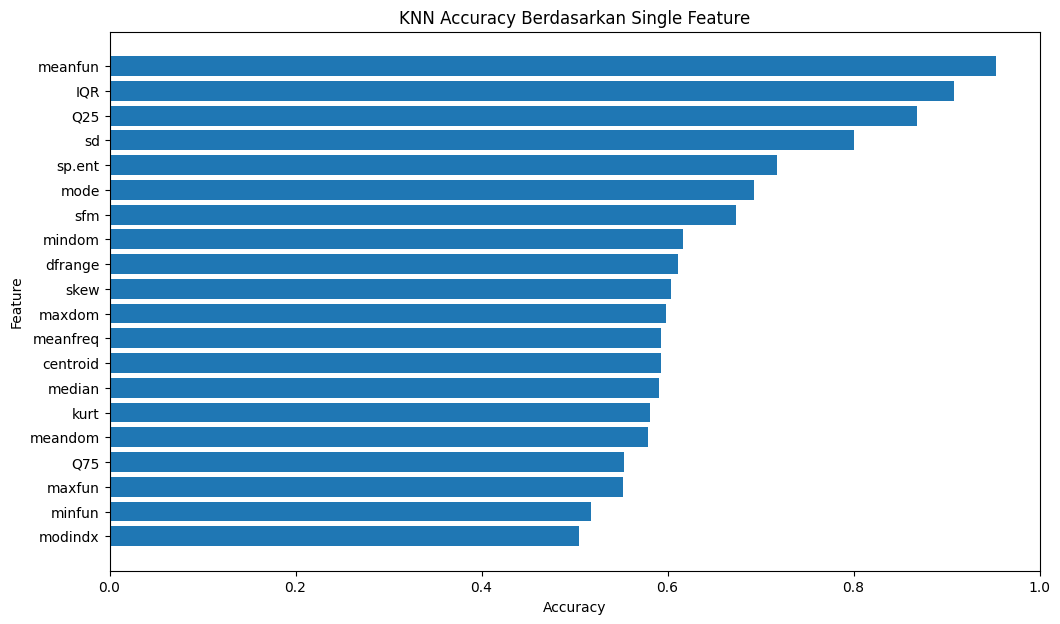

In [9]:
plt.figure(figsize=(12, 7))

plt.barh(
    feature_results_df['Feature'],
    feature_results_df['Accuracy']
)

plt.xlabel('Accuracy')
plt.ylabel('Feature')
plt.title('KNN Accuracy Berdasarkan Single Feature')
plt.xlim(0, 1)

plt.gca().invert_yaxis()
plt.show()

In [10]:
feature_ranking = feature_results_df['Feature'].tolist()

top_feature_results = []

for n in range(1, len(feature_ranking) + 1):

    selected_features = feature_ranking[:n]

    # Data sesuai fitur terpilih
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    # Standardisasi
    scaler_selected = StandardScaler()
    X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
    X_test_selected_scaled = scaler_selected.transform(X_test_selected)

    # KNN
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_selected_scaled, y_train)

    # Accuracy
    pred = model.predict(X_test_selected_scaled)
    acc = accuracy_score(y_test, pred)

    top_feature_results.append({
        'Number of Features': n,
        'Features': selected_features,
        'Accuracy': acc
    })

top_feature_results_df = pd.DataFrame(top_feature_results)

display(
    top_feature_results_df[
        ['Number of Features', 'Accuracy']
    ]
)

,Number of Features,Accuracy
0,1,0.952681
1,2,0.976866
2,3,0.978970
3,4,0.983176
4,5,0.982124
5,6,0.983176
6,7,0.984227
7,8,0.983176
8,9,0.984227
9,10,0.983176


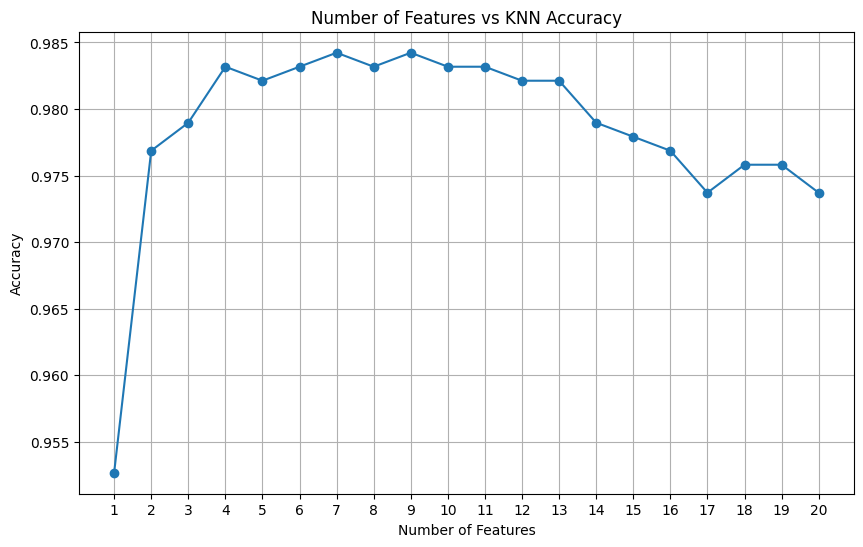

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    top_feature_results_df['Number of Features'],
    top_feature_results_df['Accuracy'],
    marker='o'
)

plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title('Number of Features vs KNN Accuracy')
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

In [12]:
best_feature_row = top_feature_results_df.loc[
    top_feature_results_df['Accuracy'].idxmax()
]

best_num_features = int(best_feature_row['Number of Features'])
best_features = best_feature_row['Features']
best_feature_accuracy = best_feature_row['Accuracy']

print("=== BEST FEATURE SET ===")
print("Number of features:", best_num_features)
print("Features:", best_features)
print("Accuracy:", best_feature_accuracy)

=== BEST FEATURE SET ===
Number of features: 7
Features: ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent', 'mode', 'sfm']
Accuracy: 0.9842271293375394


In [13]:
X_train_best = X_train[best_features]
X_test_best = X_test[best_features]

# Standardisasi fitur terbaik
scaler_best = StandardScaler()

X_train_best_scaled = scaler_best.fit_transform(X_train_best)
X_test_best_scaled = scaler_best.transform(X_test_best)

# Eksperimen K
k_results = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_best_scaled, y_train)

    train_pred = model.predict(X_train_best_scaled)
    test_pred = model.predict(X_test_best_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    k_results.append({
        'K': k,
        'Training Accuracy': train_acc,
        'Testing Accuracy': test_acc
    })

k_results_df = pd.DataFrame(k_results)

display(k_results_df)

,K,Training Accuracy,Testing Accuracy
0,1,1.000000,0.985279
1,2,0.984213,0.982124
2,3,0.988724,0.982124
3,4,0.983762,0.982124
4,5,0.984213,0.984227
5,6,0.982860,0.983176
6,7,0.981055,0.981073
7,8,0.979702,0.980021
8,9,0.980604,0.983176
9,10,0.979702,0.981073


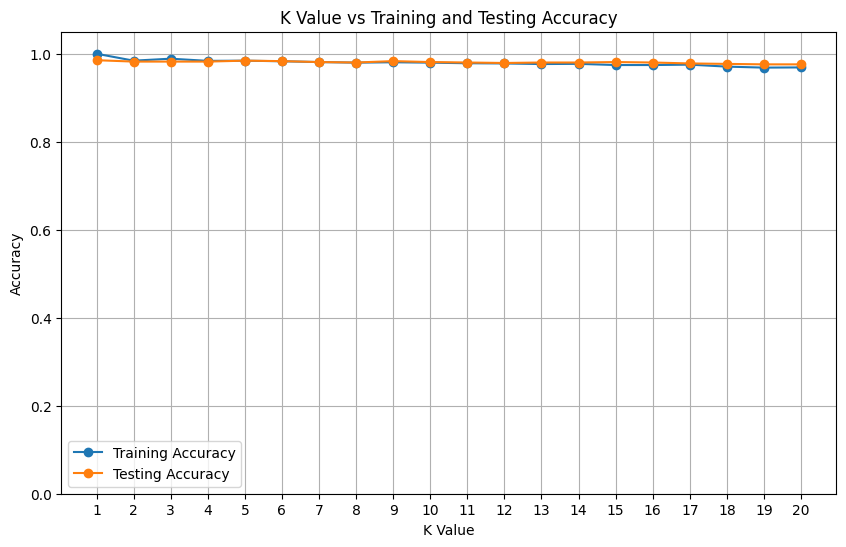

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_results_df['K'],
    k_results_df['Training Accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    k_results_df['K'],
    k_results_df['Testing Accuracy'],
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value vs Training and Testing Accuracy')
plt.xticks(range(1, 21))
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

plt.show()

In [15]:
best_k_row = k_results_df.loc[
    k_results_df['Testing Accuracy'].idxmax()
]

best_k = int(best_k_row['K'])
best_k_accuracy = best_k_row['Testing Accuracy']

print("=== BEST K ===")
print("Best K:", best_k)
print("Testing Accuracy:", best_k_accuracy)
print("Training Accuracy:", best_k_row['Training Accuracy'])

=== BEST K ===
Best K: 1
Testing Accuracy: 0.9852786540483701
Training Accuracy: 1.0


In [16]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(
    X_train_best_scaled,
    y_train
)

final_pred = final_knn.predict(X_test_best_scaled)

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

print("=== FINAL KNN MODEL ===")
print("Selected Features:", best_features)
print("Best K:", best_k)
print("Final Accuracy:", final_accuracy)

=== FINAL KNN MODEL ===
Selected Features: ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent', 'mode', 'sfm']
Best K: 1
Final Accuracy: 0.9852786540483701


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      female       0.99      0.98      0.99       476
        male       0.98      0.99      0.99       475

    accuracy                           0.99       951
   macro avg       0.99      0.99      0.99       951
weighted avg       0.99      0.99      0.99       951



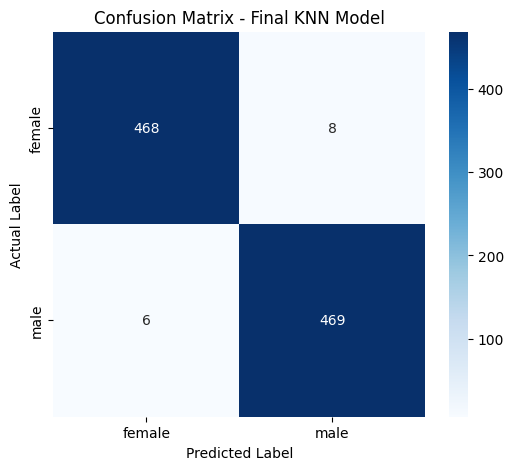

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, final_pred)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, final_pred))

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['female', 'male'],
    yticklabels=['female', 'male']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Final KNN Model')

plt.show()

In [18]:
print("=" * 50)
print("KNN VOICE CLASSIFICATION - FINAL RESULT")
print("=" * 50)

print(f"\nJumlah data          : {len(df)}")
print(f"Jumlah fitur awal    : {len(X.columns)}")
print(f"Fitur terbaik        : {best_features}")
print(f"Jumlah fitur terbaik : {best_num_features}")
print(f"Best K               : {best_k}")
print(f"Final Accuracy       : {final_accuracy:.4f}")
print(f"Final Accuracy (%)   : {final_accuracy * 100:.2f}%")

KNN VOICE CLASSIFICATION - FINAL RESULT

Jumlah data          : 3168
Jumlah fitur awal    : 20
Fitur terbaik        : ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent', 'mode', 'sfm']
Jumlah fitur terbaik : 7
Best K               : 1
Final Accuracy       : 0.9853
Final Accuracy (%)   : 98.53%


LAB ASSIGNMENT 2 — CountVectorizer

In [19]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

# Ambil hanya dua kolom yang diperlukan
df = df.iloc[:, :2]

# Rename kolom
df.columns = ['Labels', 'SMS']

# Ubah label menjadi numerik
df['Labels'] = df['Labels'].map({
    'ham': 0,
    'spam': 1
})

print(df.head())
print("\nJumlah data:")
print(df.shape)

print("\nDistribusi label:")
print(df['Labels'].value_counts())

   Labels                                                SMS
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...

Jumlah data:
(5572, 2)

Distribusi label:
Labels
0    4825
1     747
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X = df['SMS']
y = df['Labels']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (4457,)
Testing data : (1115,)


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    stop_words='english'
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Jumlah vocabulary:", len(count_vectorizer.get_feature_names_out()))
print("Training dimensions:", X_train_count.shape)
print("Testing dimensions :", X_test_count.shape)

Jumlah vocabulary: 7422
Training dimensions: (4457, 7422)
Testing dimensions : (1115, 7422)


In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

mnb_count = MultinomialNB()

mnb_count.fit(X_train_count, y_train)

# Training
y_train_pred_count = mnb_count.predict(X_train_count)
acc_train_count = accuracy_score(
    y_train,
    y_train_pred_count
)

# Testing
y_test_pred_count = mnb_count.predict(X_test_count)
acc_test_count = accuracy_score(
    y_test,
    y_test_pred_count
)

print("=== COUNT VECTORIZER ===")
print(f"Training Accuracy: {acc_train_count:.4f}")
print(f"Testing Accuracy : {acc_test_count:.4f}")

=== COUNT VECTORIZER ===
Training Accuracy: 0.9939
Testing Accuracy : 0.9821


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



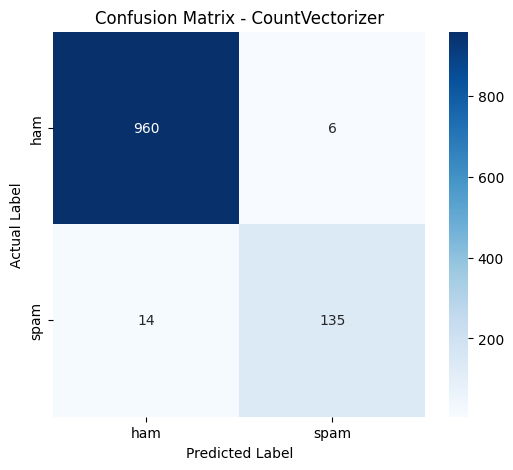

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_test_pred_count,
        target_names=['ham', 'spam']
    )
)

cm_count = confusion_matrix(y_test, y_test_pred_count)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_count,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - CountVectorizer')

plt.show()

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words='english'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Jumlah vocabulary:", len(tfidf_vectorizer.get_feature_names_out()))
print("Training dimensions:", X_train_tfidf.shape)
print("Testing dimensions :", X_test_tfidf.shape)

Jumlah vocabulary: 7422
Training dimensions: (4457, 7422)
Testing dimensions : (1115, 7422)


In [25]:
mnb_tfidf = MultinomialNB()

mnb_tfidf.fit(X_train_tfidf, y_train)

# Training
y_train_pred_tfidf = mnb_tfidf.predict(X_train_tfidf)
acc_train_tfidf = accuracy_score(
    y_train,
    y_train_pred_tfidf
)

# Testing
y_test_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)
acc_test_tfidf = accuracy_score(
    y_test,
    y_test_pred_tfidf
)

print("=== TF-IDF ===")
print(f"Training Accuracy: {acc_train_tfidf:.4f}")
print(f"Testing Accuracy : {acc_test_tfidf:.4f}")

=== TF-IDF ===
Training Accuracy: 0.9843
Testing Accuracy : 0.9731


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



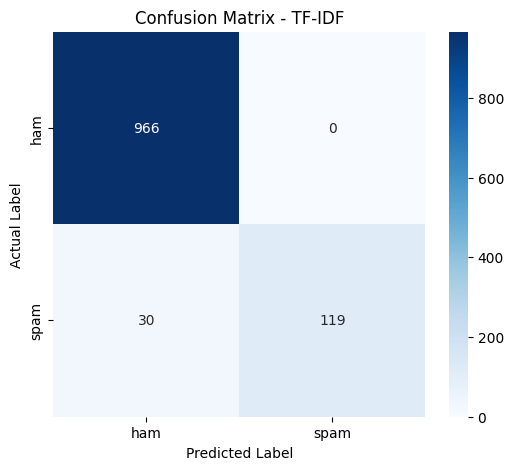

In [26]:
print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_test_pred_tfidf,
        target_names=['ham', 'spam']
    )
)

cm_tfidf = confusion_matrix(y_test, y_test_pred_tfidf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - TF-IDF')

plt.show()

In [28]:
comparison = pd.DataFrame({
    'Feature Method': [
        'CountVectorizer',
        'TF-IDF'
    ],
    'Training Accuracy': [
        acc_train_count,
        acc_train_tfidf
    ],
    'Testing Accuracy': [
        acc_test_count,
        acc_test_tfidf
    ]
})

display(comparison)

,Feature Method,Training Accuracy,Testing Accuracy
0,CountVectorizer,0.993942,0.982063
1,TF-IDF,0.984294,0.973094


In [29]:
if acc_test_count > acc_test_tfidf:
    best_method = 'CountVectorizer'
    best_accuracy = acc_test_count
elif acc_test_tfidf > acc_test_count:
    best_method = 'TF-IDF'
    best_accuracy = acc_test_tfidf
else:
    best_method = 'Both methods have the same testing accuracy'
    best_accuracy = acc_test_count

print("=== FINAL COMPARISON ===")
print("Best feature method:", best_method)
print(f"Best testing accuracy: {best_accuracy:.4f}")

=== FINAL COMPARISON ===
Best feature method: CountVectorizer
Best testing accuracy: 0.9821


In [30]:
print("=== CONCLUSION ===")

if acc_test_count > acc_test_tfidf:
    print(
        f"CountVectorizer produced the better testing accuracy "
        f"({acc_test_count:.4f}) compared with TF-IDF "
        f"({acc_test_tfidf:.4f})."
    )
    print(
        "Therefore, CountVectorizer with stop_words is the "
        "optimal feature representation for this spam.csv dataset."
    )

elif acc_test_tfidf > acc_test_count:
    print(
        f"TF-IDF produced the better testing accuracy "
        f"({acc_test_tfidf:.4f}) compared with CountVectorizer "
        f"({acc_test_count:.4f})."
    )
    print(
        "Therefore, TF-IDF with stop_words is the "
        "optimal feature representation for this spam.csv dataset."
    )

else:
    print(
        f"Both methods produced the same testing accuracy "
        f"({acc_test_count:.4f})."
    )
    print(
        "Therefore, neither feature representation is superior "
        "based on testing accuracy alone."
    )

=== CONCLUSION ===
CountVectorizer produced the better testing accuracy (0.9821) compared with TF-IDF (0.9731).
Therefore, CountVectorizer with stop_words is the optimal feature representation for this spam.csv dataset.
